# D2.2-4: GeoSphere Scientific Use Case: CO Anomalies over Europe

This notebook serves as a use case demonstrating the added value of using Sentinel-5P data from the EODC archive to investigate CO load over central Europe

We'll cover:

- accessing the EODC Zarr store using STAC
- opening the Zarr store and reading Sentinel-5P CO data with `xarray` including efficient time slicing
- interactive data analysis (raw CO load, mean annual cycle, deviations from the annual mean, selection of interesting episodes)
- plotting time series and maps

### Environment Setup

This notebook was developed using a Pixi-based Python environment for consistent and reproducible results, in particular for the geospatial stack (Cartopy, Shapely, PyProj, GDAL).

The environment can be recreated with:

```bash
pixi add \
  cartopy=0.25.0 \
  shapely=2.1.2 \
  pyproj=3.7.2 \
  matplotlib=3.10.8 \
  numpy=2.4.0 \
  xarray=2025.12.0 \
  zarr=3.1.5 \
  rasterio=1.4.4 \
  rioxarray=0.20.0 \
  geopandas=1.1.2 \
  ipykernel \
  pystac-client \
  fsspec \
  aiohttp \
  requests
```

### General import statements

We import all required libraries for data access, analysis, and visualisation.

In [11]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pystac_client
import fsspec
import zarr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Transformer
from pyproj import CRS

### Functions

We start with defining functions, which will be used later on in the workflow.

These include:
- access to the EODC STAC catalogue
- opening the Zarr data cube
- reading and filtering Sentinel-5P data
- extracting plotting configuration (CRS and visualisation settings)  
- creating map visualisations  

Execute these functions but do not modify them.

In [12]:
# This function provides access to the EODC Zarr store using STAC
def get_collection():
    eodc_stac = "https://stac.eodc.eu/api/v1"
    collection_id = "SENTINEL5P_DAILY_AUT"

    eodc_catalog = pystac_client.Client.open(eodc_stac)
    collection = eodc_catalog.get_collection(collection_id)
    return(collection)

# This function opens the EODC Sentinel-5P archive
def get_ds(input):
    collection = get_collection()

    # Zarr store URL (this is NOT a file, but a "virtual filesystem")
    store_url = collection.get_single_link("store").href

    # Open the Sentinel-5P archive
    ds = xr.open_zarr(store_url, group=input["product_type"], consolidated=True)
    return ds

# This function reads Sentinel-5P data with `xarray` and performs time slicing and variable extraction. 
# Furthermore, it checks if the dataset has been decoded correctly.
def read_data(input):
    collection = get_collection()
    ds = get_ds(input)

    # Open the Sentinel-5P archive
    dats = ds[input["product_spec"][input["product_type"]]["variable"]]
    
    # select data (qa_threshold and time slicing)
    dats = dats.sel(qa_threshold=input["product_spec"][input["product_type"]]["qflag"])
    dats = dats.sel(time=slice(input["start_date"], input["end_date"]))

    # Handling missing and fill values (sanity check)
    # By default, **xarray** automatically decodes CF-compliant metadata, including `_FillValue`, and converts declared missing values to `NaN`.
    # Even so, performing a brief sanity check is good practice to confirm that the dataset has been decoded correctly and is ready for analysis.
    # We can retrieve the "nodata" and "scale" value from STAC:
    asset = collection.to_dict()["assets"][input["product_type"]]["raster:bands"][0]
    nodata = asset["nodata"]
    scale = asset["scale"]
    print("nodata:", nodata)
    print("scale:", scale)

    # Optional masking (usually not needed)
    if nodata is not None:
        dats = dats.where(dats != nodata) # Usually unnecessary — xarray already handled this

    # How many NaNs are there?
    n_missing = dats.isnull().compute().sum().item()
    n_valid = dats.notnull().compute().sum().item()
    print(f"Number of missing values (NaN): {n_missing}")
    print(f"Number of valid values: {n_valid}")

    # Optionally, check min/max to see if fill values were decoded
    print("Min value:", float(dats.min()))
    print("Max value:", float(dats.max()))

    return(dats)

# This function creates map plots
def plot_map(data, plot_data, plot_spec, variable, crs=27704):

    # --- 1. Color scale limits ---
    plot_min = plot_spec["min"] if plot_spec["min"] is not None else plot_data.min()
    plot_max = plot_spec["max"] if plot_spec["max"] is not None else plot_data.max()

    # --- 2. Grid coordinates ---
    X, Y = np.meshgrid(data["x"].values, data["y"].values)

    # --- 3. Define the CRS and Cartopy projection ---
    crs_custom = CRS.from_epsg(crs)
    proj = ccrs.Projection(crs_custom)

    # --- 4. Create the figure and axis ---
    fig, ax = plt.subplots(
        figsize=plot_spec["figsize"],
        subplot_kw={"projection": proj}
    )
    
    # --- 5. Add map features ---
    ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')

    # --- 6. Set the map extent ---
    if plot_spec["extent"] is not None:
        ax.set_extent(plot_spec["extent"], crs=proj)

    ax.set_title(plot_spec["title"])

    # --- 7. Plot the data ---
    im = ax.pcolormesh(
        X, Y, plot_data,
        cmap=plot_spec["cbar"],
        vmin=plot_min,
        vmax=plot_max,
        transform=proj
    )

    # --- 8. Add xlabel and ylabel ---
    if "xlabel" in plot_spec:
        ax.set_xlabel(plot_spec["xlabel"])
    if "ylabel" in plot_spec:
        ax.set_ylabel(plot_spec["ylabel"])

    # --- 9. Add grid lines ---
    if plot_spec.get("grid", True):
        ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)

    # --- 10. Add colorbar ---
    cbar = fig.colorbar(
        im, ax=ax, orientation='horizontal',
        fraction=0.046, pad=0.046
    )
    cbar.set_label(f"{variable} load")

    # --- 11. Show the plot ---
    plt.tight_layout()
    plt.show()

def get_plot_config(data):
    """
    Extract CRS and define plotting configs in a robust way.
    """

    from pyproj import CRS

    # --- Try different ways to get CRS ---
    crs = None

    try:
        # Most common case (CF / raster datasets)
        crs = CRS.from_cf(data["spatial_ref"].attrs)
    except Exception:
        try:
            # Fallback: WKT (if available)
            crs = CRS.from_wkt(data["spatial_ref"].attrs["crs_wkt"])
        except Exception:
            # Last fallback: assume known CRS (EODC grid)
            print("⚠️ Could not extract CRS automatically, using fallback EPSG:27704")
            crs = CRS.from_epsg(27704)

    crs_str = f"EPSG:{crs.to_epsg()}" if crs.to_epsg() else str(crs)

    # --- Plot configs ---
    plot_spec_clim = {
        "figsize": (8, 8),
        "cbar": "viridis",
        "min": 0.025,
        "max": 0.05,
        "extent": None,
        "grid": True
    }

    plot_spec_event = {
        "figsize": (8, 8),
        "cbar": "viridis", # "inferno",
        "min": 0.025, # 0.03,
        "max": 0.05, # 0.08,
        "extent": None,
        "grid": True
    }

    return crs_str, plot_spec_clim, plot_spec_event

# Start of the main program

## Analysis Setup
In a first step, we define input data including
- the product type (can be  "CO", "O3", "CH4", "NO2", "SO2", "HCHO", "CLOUD", "AER_AI"),
- its quality flag (0., 0.5, 0.75 for all variables),
- and start_date and end_date (data are currently available from 2018-07-05 to 2026-03-31).


In [13]:
# Define input parameters
input = {}
# potential products: "CO", "O3", "CH4", "NO2", "SO2", "HCHO", "CLOUD", "AER_AI"
input["product_type"] = "CO"


# Time range (available data: 2018-07-05 to 2026-03-31)
input["start_date"] = "2019-01-01"
input["end_date"] = "2025-12-31"

# potential qflags: 0.  , 0.5 , 0.75 for all variables
input["product_spec"] = {"CO": {"variable": "carbonmonoxide_total_column", "qflag": 0.5}}

## Data Access and Preparation

We now load the Sentinel-5P CO data cube and apply filtering:

- select the relevant variable
- apply quality threshold
- restrict to selected time period

The resulting dataset forms the basis for all further analysis.


In [14]:
data = read_data(input)

nodata: 9.969209968386869e+36
scale: 1.0
Number of missing values (NaN): 13683606
Number of valid values: 14317367
Min value: 0.001267936546355486
Max value: 0.19576318562030792


## Baseline CO Behaviour

As a first step, we analyse the overall CO load by computing
a spatial average across the domain.

This provides a time series describing the general behaviour
of atmospheric CO over Central Europe.


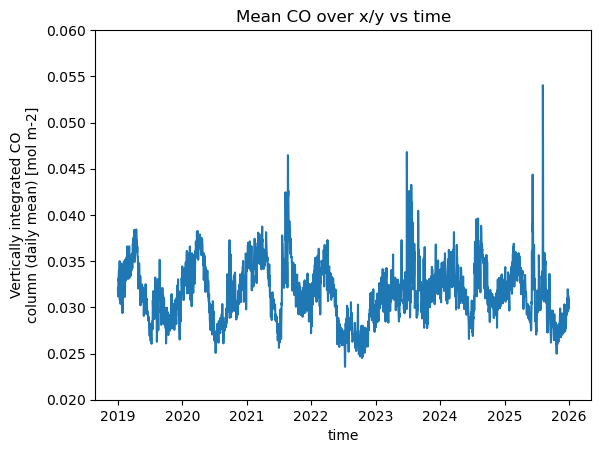

In [15]:
# Plot "raw" time series of the spatial mean (obtained from the entire domain)

spatial_mean = data.mean(dim=("y","x"))

ymin = 0.02
ymax = 0.06
    
fig, ax = plt.subplots()
spatial_mean.plot(ax=ax)
ax.set_title("Mean "+input["product_type"]+" over x/y vs time")
if ymin is not None and ymax is not None:
    ax.set_ylim((ymin, ymax))
    
plt.show()

## Temporal Aggregation: Mean Annual Cycle

To better understand typical behaviour, we compute the mean annual cycle of spatially averaged CO concentrations (obtained from the entire domain).

This allows us to identify seasonal patterns.

Typically:
- higher CO values occur in winter
- lower values occur in summer
reflecting changes in emissions and atmospheric chemistry.


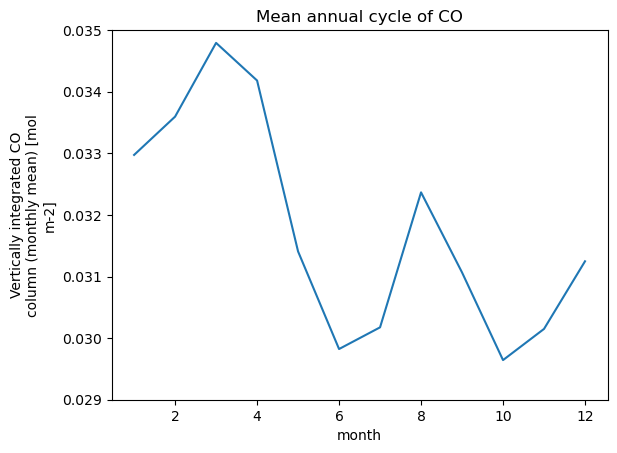

In [16]:
mean_annual_cycle = data.groupby("time.month").mean("time")
spatial_mean_clim = mean_annual_cycle.mean(dim=("y", "x"))
spatial_mean_clim.attrs['long_name'] = "Vertically integrated CO column (monthly mean)"

ymin = 0.029
ymax = 0.035

fig, ax = plt.subplots()
spatial_mean_clim.plot(ax=ax)
ax.set_title("Mean annual cycle of " + input["product_type"])

if ymin is not None and ymax is not None:
    ax.set_ylim((ymin, ymax))

plt.show()


## Comparison: Climatology vs Observations

We now compare:
- the climatological annual cycle (typical behaviour)
- the actual monthly evolution

So we Plot the time series of the spatial mean together with the mean annual cycle (both obtained from the entire domain). This allows us to identify deviations from expected conditions.


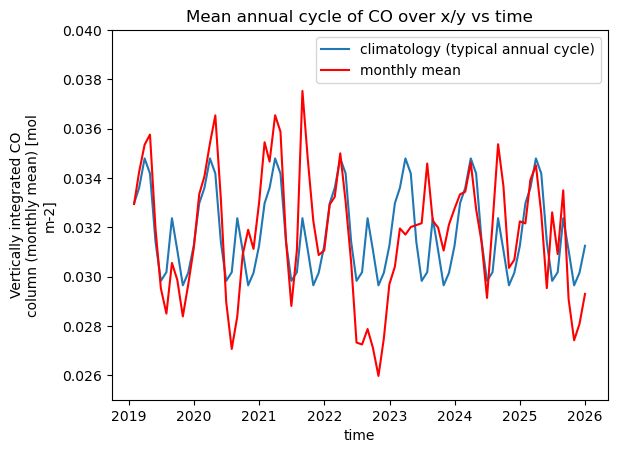

In [17]:
no_years = data.resample(time="1ME").mean()["time"].size / 12.
    
mean_annual_cycle = data.groupby("time.month").mean("time")
mean_annual_cycle = mean_annual_cycle.expand_dims(dim={"year": int(no_years)})
mean_annual_cycle = mean_annual_cycle.stack(time=("year", "month"))

spatial_mean_clim = mean_annual_cycle.mean(dim=("y","x"))
spatial_mean_clim = spatial_mean_clim.drop_vars(["time", "year", "month"], errors="ignore")
spatial_mean_clim["time"] = data.resample(time="1ME").mean()["time"]
spatial_mean_clim.attrs['long_name'] = "Vertically integrated CO column (monthly mean)"

monthly_means = data.resample(time='1ME').mean()
spatial_mean_mm = monthly_means.mean(dim=("y","x"))
spatial_mean_mm.attrs['long_name'] = "Vertically integrated CO column (monthly mean)"

ymin = 0.025
ymax = 0.04

fig, ax = plt.subplots()
spatial_mean_clim.plot(ax=ax, label="climatology (typical annual cycle)")
spatial_mean_mm.plot(ax=ax, color='red', label="monthly mean")
ax.set_title("Mean annual cycle of "+input["product_type"]+" over x/y vs time")
if ymin is not None and ymax is not None:
    ax.set_ylim((ymin, ymax))
ax.legend()
plt.show()

## Deviations from Typical Behaviour

We compute the difference between observed values and the
climatological annual cycle.

This highlights anomalous periods where CO concentrations
significantly exceed typical levels.

We define extreme pollution episodes as values above the
90th percentile.


Extreme CO anomaly events (above 90th percentile):

2020-04-30T00:00:00.000000000
2021-01-31T00:00:00.000000000
2021-08-31T00:00:00.000000000
2021-09-30T00:00:00.000000000
2021-10-31T00:00:00.000000000
2023-07-31T00:00:00.000000000
2024-08-31T00:00:00.000000000
2024-09-30T00:00:00.000000000
2025-06-30T00:00:00.000000000
90th percentile anomaly threshold: [0.0023516]


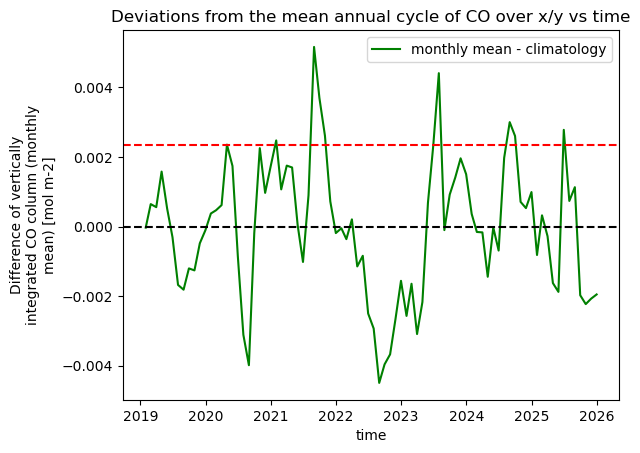

In [18]:
# Calculate and plot the difference between the spatial mean and the mean annual cycle 
# and extract months with "extreme" air pollution (values > 0.9 quantile)

diff = spatial_mean_mm - spatial_mean_clim
diff.attrs['long_name'] = "Difference of vertically integrated CO column (monthly mean)"
quantile = np.quantile(diff, [0.9])

print("Extreme CO anomaly events (above 90th percentile):\n")
for dd in diff[np.where(diff >= quantile)]: print(dd.time.values)

print(f"90th percentile anomaly threshold: {quantile}")

fig, ax = plt.subplots()
diff.plot(ax=ax, color="green", label="monthly mean - climatology")
ax.set_title("Deviations from the mean annual cycle of "+input["product_type"]+" over x/y vs time")
ax.legend()
ax.axhline(quantile, linestyle="--", color="red")
ax.axhline(0, linestyle="--", color="black")
plt.show()

### Interpretation

The identified peaks correspond to periods with unusually high CO concentrations compared to the typical seasonal cycle.

These anomalies indicate episodes of enhanced atmospheric pollution and represent interesting cases for further investigation.


## Selection of Interesting Episodes

Based on the anomaly analysis and the plot above, we identify several periods
with elevated CO concentrations, e.g.:

- August 2021
- July 2023
- August / September 2024
- June 2025

We now focus on one representative case.


### Case Study: August 2021

Let's have a look at August 2021 and compare it to the climatological August loads!


Using CRS: EPSG:27704


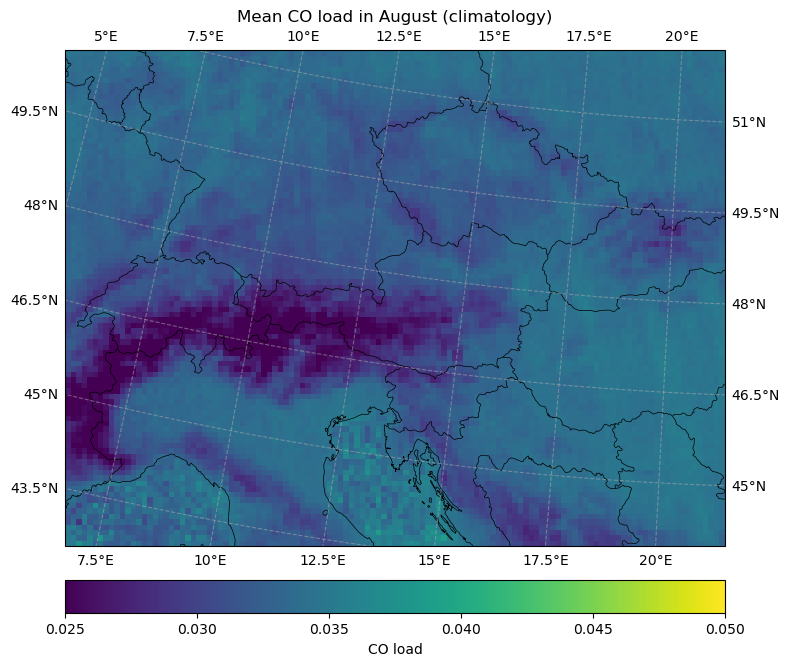

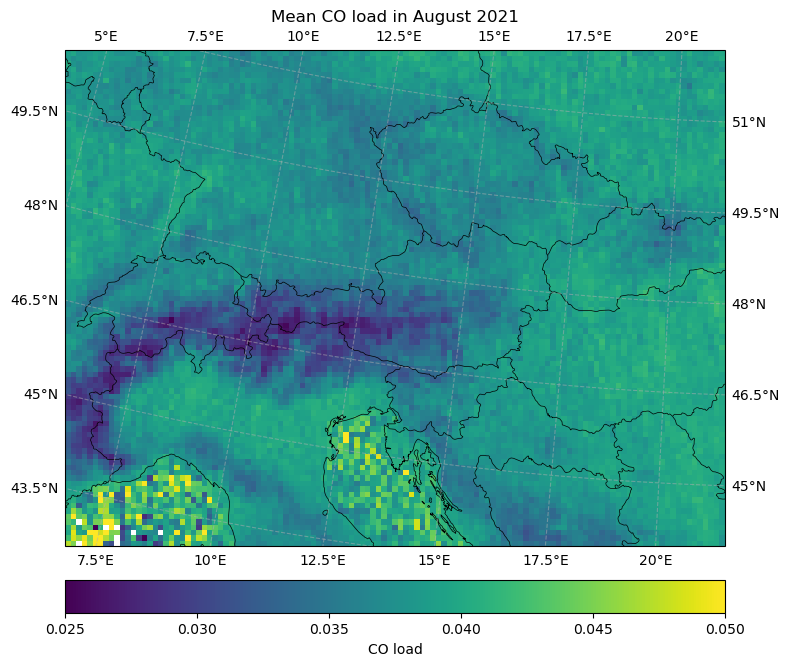

In [19]:
crs, plot_spec_clim, plot_spec_event = get_plot_config(data)

print(f"Using CRS: {crs}")

epi_name = "Aug 2021"

if epi_name == "Aug 2021":
    epi_month_long = "August"
    episode = np.datetime64('2021-08-31')

epi_month = episode.astype('datetime64[M]').astype(int) % 12 + 1
epi_year = episode.astype('datetime64[Y]').astype(int) + 1970

variable = input["product_type"]

mean_annual_cycle = data.groupby("time.month").mean("time")

plot_spec_clim["title"] = f"Mean {variable} load in August (climatology)"

dat = mean_annual_cycle.sel(month=epi_month).squeeze()
plot_map(data, dat, plot_spec_clim, variable)

monthly_means = data.resample(time='1ME').mean()
plot_spec_event["title"] = f"Mean {variable} load in August {epi_year}"
dat = monthly_means.sel(time=episode).squeeze()
plot_map(data, dat, plot_spec_event, variable)


### Temporal Evolution during the Event

Where do these high concentrations come from?

To investigate this, we analyse the temporal evolution of
CO concentrations by plotting the time series of the spatial
mean CO load during August 2021.


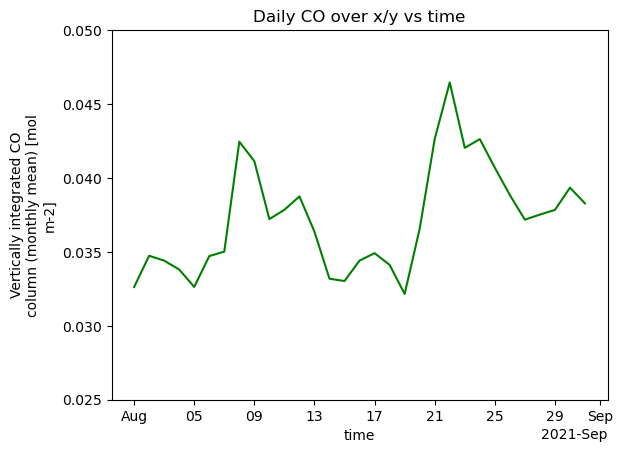

In [20]:
epi_tt_start = np.datetime64('2021-08-01')
epi_tt_end = np.datetime64('2021-08-31')

ymin = 0.025
ymax = 0.05

dat = data.sel(time=slice(epi_tt_start, epi_tt_end))
    
spatial_mean_mm = dat.mean(dim=("y","x"))
spatial_mean_mm.attrs['long_name'] = "Vertically integrated CO column (monthly mean)"
fig, ax = plt.subplots()
spatial_mean_mm.plot(ax=ax, color="green")
ax.set_title("Daily "+input["product_type"]+" over x/y vs time") 
if ymin is not None and ymax is not None:
    ax.set_ylim((ymin, ymax))
plt.show()

The time series shows pronounced peaks, indicating
short-term episodes of very high CO concentrations.

### Spatial Patterns

We now investigate spatial patterns to identify possible
emission sources.


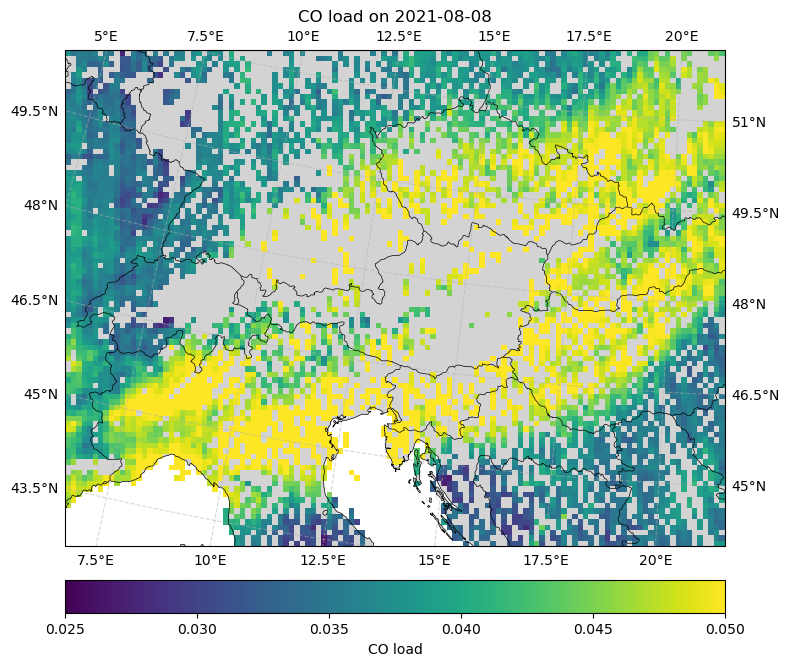

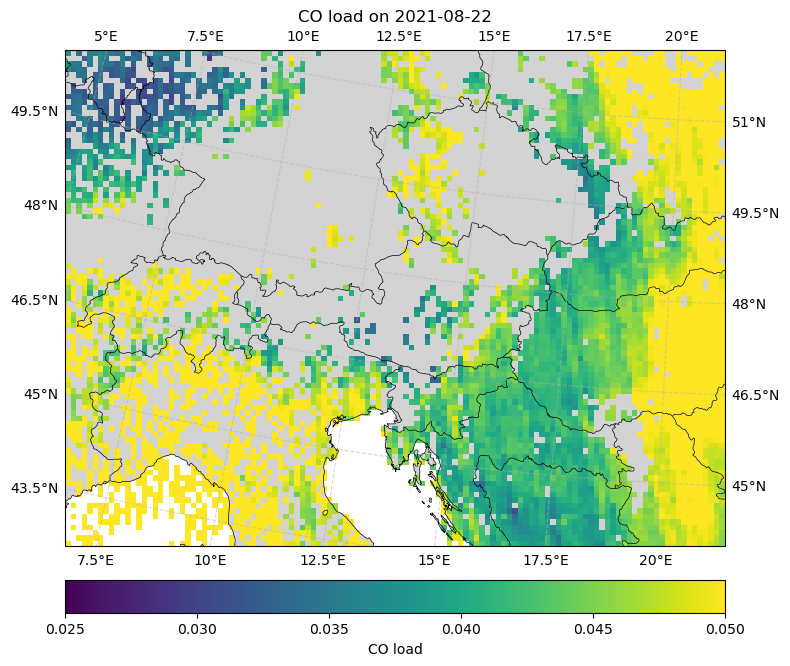

In [21]:
epi_date = '2021-08-08'   
plot_spec_event["title"] = input["product_type"]+" load on "+epi_date
dat = data.sel(time=np.datetime64(epi_date)).squeeze()
plot_map(data, dat, plot_spec_event, variable)

epi_date = '2021-08-22'   
plot_spec_event["title"] = input["product_type"]+" load on "+epi_date
dat = data.sel(time=np.datetime64(epi_date)).squeeze()
plot_map(data, dat, plot_spec_event, variable)

These high CO loads were associated with multiple fires across Europe, which released large amounts of carbon monoxide and contributed to the elevated concentrations observed over the study area.

## Conclusion

We demonstrated how Sentinel-5P CO data can be used to
analyse atmospheric composition and detect anomalous
pollution events.

Elevated CO levels observed in the data can be associated
with large-scale fire activity across Europe.

This highlights the value of satellite observations and
cloud-based data access for Earth observation applications.
